# 264: the three combiners, the single best pair, phmmer and a Kyte-Doolittle scan on the test split

One table and two figures over the **test split only**, from the settings frozen on the tune
split by [notebook 261](261_combiner_a_intersection_panel.ipynb) (combiner A, intersection),
[notebook 262](262_combiner_b_best_of_n.ipynb) (combiner B, best of n, corrected E-value) and
[notebook 263](263_combiner_c_consensus_vote.ipynb) (combiner C, consensus vote). Nothing is
fitted here: every threshold, panel and vote count is read from their yaml files.

**Question.** Which way of combining kmerseek's alphabet-ksize pairs (one reduced amino-acid
alphabet at one k-mer size) gives the fewest candidate regions for the same recall, and does
any of them find more of the Pfam domains in multi-domain human proteins than phmmer?

**Decision rule** (set after reading the outputs of 261-263, before this notebook ran). A
combiner beats the single best pair when, on test, it has Pfam recall at least as high with
no more calls per query, and is strictly better on one of the two. If no combiner does, the
answer is "none of them beat the single best pair", and the full run (more alphabets, more
species, the shuffled-query twin) is needed before choosing one.

**Rows.**

| row | what is called | frozen in |
|---|---|---|
| single best pair | merged regions (built from all 4 pairs' calls) in which the pair encoded hp_pbotc_1st_ed2 k=19, extension penalty 2, has a call at E-value <= 9.97; this is how 262 and 263 scored it, not the pair's own calls | [262](262_combiner_b_best_of_n.ipynb), `single_pair_threshold` |
| A, intersection | merged regions both panel pairs call at E-value < 10 | [261](261_combiner_a_intersection_panel.ipynb), `panel`, `emax` |
| B, best of n | merged regions whose lowest E-value over the 4 pairs, times 4, is <= 39.9; on this table that keeps every merged region | [262](262_combiner_b_best_of_n.ipynb), `threshold` |
| C, consensus vote | merged regions with at least 1 vote (one per cluster of pairs) at E-value < 10; the 4 pairs are one cluster, so this also keeps every merged region | [263](263_combiner_c_consensus_vote.ipynb), `v_min`, `emax`, `clusters` |
| phmmer | phmmer's per-domain hits at i-Evalue < 10 (two ways, below) | the cut 261 and 262 used |
| Kyte-Doolittle scan | 19-residue windows with mean hydropathy above 1.6; reads only the query; the frozen threshold equals the scan's own cut, so it removes nothing | [262](262_combiner_b_best_of_n.ipynb), tune threshold |

**Columns.**
- *calls per query*: called regions / (test queries x target species).
- *precision*: called regions with at least half their length inside one truth feature /
  called regions on queries that have any feature of that truth set. Higher is better.
- *recall*: truth features with at least one call putting half of itself inside / all truth
  features on test queries, once per target species. Two truth sets: Swiss-Prot features
  (DOMAIN, REGION, TRANSMEM, REPEAT and the other feature keys) and Pfam domains. Higher is
  better.
- *shuffled-query calls per query*: the same, on human proteins with residues shuffled in
  pairs, which have no homolog; every such call is false. Lower is better.
- *Pfam domains landed per multi-domain query*: for test queries with at least two Pfam
  domains, how many of those domains at least one call puts half of itself inside, mean over
  queries. Higher is better.
- *median boundary error*: for each Pfam domain found, the call landed in it whose ends are
  closest to the domain's ends; error = (|call start - domain start| + |call end - domain
  end|) / 2, in residues. Median over found domains. Lower is better.

**Where each number comes from.** The last three columns, phmmer's precision and recall,
and the Kyte-Doolittle domain count were never computed in 261-263; they are computed here
from the same files. Every number 261-263 did print is recomputed here with one shared
scoring function and checked against the printed value; the provenance table lists the
notebook and cell for each.

**Data.** midi-plus region benchmark rerun with kmerseek 0.4 and extension
(`~/data/qfo-pfam-region-midi-plus-0.4/`): 998 human queries (QfO 2020_04 reference
proteome) against the zebrafish proteome. The region table notebook 260 built
(`260_region_table/region_table.parquet`) holds 4 pairs, all hp_pbotc_1st_ed2 at k=19, and
no shuffled-query run exists yet. phmmer (HMMER3 single-sequence search) comes from the
midi-plus region benchmark run (1-2 Sept 2026), the same queries against the same zebrafish
proteome.

In [1]:
import hashlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from matplotlib.lines import Line2D

sys.path.insert(0, str(Path.cwd()))
import mhc_region_utils as mu
import pubfig as pf
import region_combiner_261 as rc
import region_combiner_262 as rb
import region_combiner_263 as rv
import region_table_260 as rt

pf.use_style()
pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_width_chars(250)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(60)

BASE = Path.home() / "data" / "qfo-pfam-region-midi-plus-0.4" / "260_region_table"
TABLE = BASE / "region_table.parquet"
TRUTH_PAIRS = BASE / "region_table_truth_pairs.parquet"
REDUCED = BASE / "reduced"
DECOY_TABLE = BASE / "region_table_decoy.parquet"
DECOY_REDUCED = BASE / "reduced_decoy"
PFAM_TRUTH = mu.MIDI_DIR / "truth" / "human_domain_truth.parquet"
SWISSPROT_TRUTH = mu.MIDI_DIR / "truth_swissprot" / "human_swissprot_truth.parquet"
QUERY_MAP = mu.MIDI_DIR / "query_gene_map.parquet"
PHMMER_DIR = mu.MIDI_DIR / "regions" / "hmmer3_phmmer"
FIG = Path.cwd().parent / "figures"
SPLIT = "test"

def sha256(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()

Y = {n: yaml.safe_load((Path.cwd() / f).read_text()) for n, f in
     (("A", "261_intersection_panel.yaml"), ("B", "262_best_of_n_threshold.yaml"),
      ("C", "263_consensus_vote.yaml"))}
TABLE_SHA = sha256(TABLE)
for n, y in Y.items():
    assert y["input_table_sha256"] == TABLE_SHA, f"combiner {n}'s yaml was written from a different table"

table = pl.read_parquet(TABLE)
truth_pairs = pl.read_parquet(TRUTH_PAIRS)
truth = rt.load_truth(PFAM_TRUTH, SWISSPROT_TRUTH)
tried = rb.arms_tried(pl.read_parquet(REDUCED / "reduce_summary.parquet"))
calls = rb.merged_calls(REDUCED, table)  # raises if the re-merge differs from the table
scores = rb.attach_truth(rb.region_scores(calls, tried), table)
queries = pl.read_parquet(QUERY_MAP).select("accession", "hgnc_symbol").with_columns(
    split=rt.query_split(pl.col("accession")))
SPECIES = sorted(scores["species"].unique().to_list())
ARMS = sorted(calls["arm"].unique().to_list())
N_QUERY_SPECIES = queries.filter(pl.col("split") == SPLIT).height * len(SPECIES)

print(f"{TABLE}: {table.height:_} rows, sha256 {TABLE_SHA[:16]} (same in all three yaml files)")
print(f"pairs: {ARMS}")
print(f"target species: {SPECIES}")
print(f"{SPLIT} queries x species: {N_QUERY_SPECIES}")
print(f"shuffled-query table: {'present' if DECOY_TABLE.exists() else 'absent'}; "
      f"reduced shuffled-query calls: {'present' if DECOY_REDUCED.exists() else 'absent'}")
print("frozen settings read:")
print(f"  single best pair: {Y['B']['single_pair']} at E-value <= {Y['B']['single_pair_threshold']:.4g}")
print(f"  A: panel {Y['A']['panel']}, E_max {Y['A']['emax']:g}")
print(f"  B: {Y['B']['rank_score']} <= {Y['B']['threshold']:.4g}")
print(f"  C: v_min {Y['C']['v_min']}, E_max {Y['C']['emax']:g}, {Y['C']['counting']}, clusters {Y['C']['clusters']}")
print(f"  Kyte-Doolittle: best window mean >= "
      f"{next(r['threshold'] for r in Y['B']['tune_thresholds_all_scores'] if r['method'] == 'Kyte-Doolittle' and r['truth_set'] == Y['B']['frozen_on_truth_set']):.3g}")

/Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet: 6_140 rows, sha256 c936f3884dbbb25f (same in all three yaml files)
pairs: ['encoded_hp_pbotc_1st_ed2_k19_ext1.63', 'encoded_hp_pbotc_1st_ed2_k19_ext2', 'hp_pbotc_1st_ed2_k19_ext1.63', 'hp_pbotc_1st_ed2_k19_ext2']
target species: ['zebrafish']
test queries x species: 487
shuffled-query table: absent; reduced shuffled-query calls: absent
frozen settings read:
  single best pair: encoded_hp_pbotc_1st_ed2_k19_ext2 at E-value <= 9.974
  A: panel ['encoded_hp_pbotc_1st_ed2_k19_ext1.63', 'encoded_hp_pbotc_1st_ed2_k19_ext2'], E_max 10
  B: evalue_best_of_n_corrected <= 39.9
  C: v_min 1, E_max 10, one per cluster, clusters {'encoded_hp_pbotc_1st_ed2_k19_ext1.63': 0, 'encoded_hp_pbotc_1st_ed2_k19_ext2': 0, 'hp_pbotc_1st_ed2_k19_ext1.63': 0, 'hp_pbotc_1st_ed2_k19_ext2': 0}
  Kyte-Doolittle: best window mean >= 1.6


## The called regions of each row

Each row becomes one list of called regions on test queries: accession, target species,
start and end on the query (1-based, inclusive). The kmerseek rows use the merged-region
extents of [notebook 260](260_kmerseek_region_table.ipynb). phmmer is given two ways:
- *each hit*: every per-domain hit is one call, as notebooks 261-263 counted it for the
  multi-domain question;
- *hits merged*: hits on the same query and species joined by notebook 260's rule for
  kmerseek (two calls join when they overlap by at least half of the shorter, and chains
  join), so its calls per query count stretches of the query the way kmerseek's do.

The figure shows how many regions each row calls and how long they are.

shape: (7, 5)
┌─────────────────────┬──────────┬────────────┬───────────────┬────────────┐
│ row                 ┆ n_called ┆ length_q25 ┆ length_median ┆ length_q75 │
│ ---                 ┆ ---      ┆ ---        ┆ ---           ┆ ---        │
│ str                 ┆ u32      ┆ f64        ┆ f64           ┆ f64        │
╞═════════════════════╪══════════╪════════════╪═══════════════╪════════════╡
│ single best pair    ┆ 795      ┆ 104.0      ┆ 170.0         ┆ 296.0      │
│ A, intersection     ┆ 720      ┆ 119.0      ┆ 186.5         ┆ 318.0      │
│ B, best of n        ┆ 822      ┆ 104.0      ┆ 166.5         ┆ 293.0      │
│ C, consensus vote   ┆ 822      ┆ 104.0      ┆ 166.5         ┆ 293.0      │
│ phmmer, each hit    ┆ 87244    ┆ 76.0       ┆ 115.0         ┆ 175.0      │
│ phmmer, hits merged ┆ 571      ┆ 192.0      ┆ 327.0         ┆ 535.0      │
│ Kyte-Doolittle scan ┆ 789      ┆ 19.0       ┆ 21.0          ┆ 27.0       │
└─────────────────────┴──────────┴────────────┴───────────────

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_74380/1722599886.py:108: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.92))


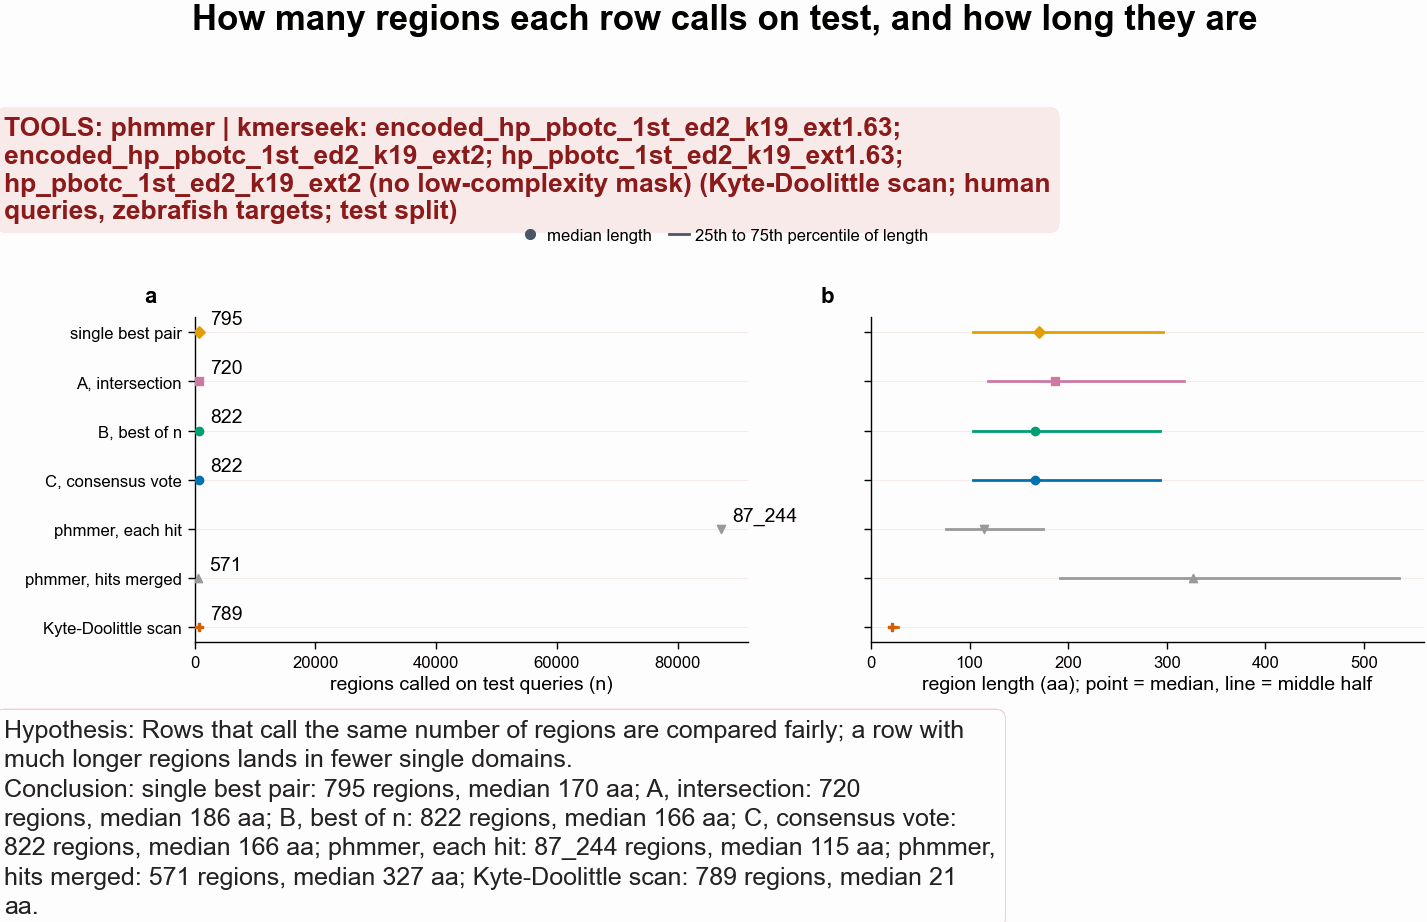

In [2]:
def kmerseek_spans(df: pl.DataFrame) -> pl.DataFrame:
    return df.select("accession", "species", start="merged_start", end="merged_end")

test_scores = scores.filter(pl.col("split") == SPLIT)

# Single best pair, scored on its own as notebook 262 did (n_arms_tried = 1).
SINGLE, THR_SINGLE = Y["B"]["single_pair"], Y["B"]["single_pair_threshold"]
ONE = tried.with_columns(n_arms_tried=pl.lit(1, pl.UInt32))
single_scores = rb.attach_truth(rb.region_scores(calls.filter(pl.col("arm") == SINGLE), ONE), table)
spans = {"single best pair": kmerseek_spans(
    single_scores.filter((pl.col("split") == SPLIT) & (pl.col("evalue_min") <= THR_SINGLE)))}

# A: every panel pair calls the merged region at E < emax.
scorer_a = rc.Scorer(table, truth_pairs, truth, SPLIT)
a_rid = scorer_a.called(Y["A"]["panel"], Y["A"]["emax"])
spans["A, intersection"] = kmerseek_spans(
    scorer_a.regions.filter(pl.col("rid").is_in(a_rid))
    .join(scorer_a.t.unique(subset=rc.KEY).select(rc.KEY + ["merged_start", "merged_end"]), on=rc.KEY))

# B: corrected best-of-n E-value at or below the frozen threshold.
assert Y["B"]["rank_score"] == rb.RANK_SCORE
spans["B, best of n"] = kmerseek_spans(test_scores.filter(pl.col(rb.RANK_SCORE) <= Y["B"]["threshold"]))

# C: votes at E < emax, one per cluster of pairs, at least v_min.
per_arm = rv.per_arm_best(calls).join(test_scores.select(rv.KEY), on=rv.KEY)
v = rv.votes(per_arm, Y["C"]["emax"], Y["C"]["clusters"])
vote_col = {"one per cluster": "n_cluster_votes", "every pair": "n_votes"}[Y["C"]["counting"]]
c_keys = v.filter(pl.col(vote_col) >= Y["C"]["v_min"]).select(rv.KEY)
spans["C, consensus vote"] = kmerseek_spans(test_scores.join(c_keys, on=rv.KEY))

# phmmer at i-Evalue < 10, each hit and merged with notebook 260's rule.
phm = pl.concat([rc.load_phmmer(PHMMER_DIR / f"human_vs_{sp}.hmmer3_phmmer.tsv.gz", sp) for sp in SPECIES])
phm = (phm.filter(pl.col("evalue") < rt.EVALUE_MAX)
       .with_columns(split=rt.query_split(pl.col("accession")))
       .filter(pl.col("split") == SPLIT)
       .select("accession", "species", start="qstart", end="qend"))
spans["phmmer, each hit"] = phm

def merge_spans(s: pl.DataFrame) -> pl.DataFrame:
    # Notebook 260's merge rule (rt.merge_group) on any calls; returns one row per merged stretch.
    parts = []
    for _, g in s.sort("accession", "species", "start", "end").group_by(["accession", "species"], maintain_order=True):
        lab = rt.merge_group(g["start"].to_numpy(), g["end"].to_numpy())
        parts.append(g.with_columns(m=pl.Series(lab, dtype=pl.Int64)))
    return (pl.concat(parts).group_by("accession", "species", "m")
            .agg(pl.col("start").min(), pl.col("end").max()).drop("m"))

spans["phmmer, hits merged"] = merge_spans(phm)

# Kyte-Doolittle scan at its frozen tune threshold.
THR_KD = next(r["threshold"] for r in Y["B"]["tune_thresholds_all_scores"]
              if r["method"] == "Kyte-Doolittle" and r["truth_set"] == Y["B"]["frozen_on_truth_set"])
nf_test = rb.n_features(truth, SPLIT, len(SPECIES))
seqs = rb.load_query_seqs(queries["accession"].to_list())
kd = rb.kd_calls(seqs, truth, SPECIES, SPLIT, nf_test)
spans["Kyte-Doolittle scan"] = kd.regions.filter(pl.col("kd_score") >= THR_KD).select("accession", "species", "start", "end")

ROWS = list(spans)
lengths = pl.concat([s.select(row=pl.lit(r), length=pl.col("end") - pl.col("start") + 1) for r, s in spans.items()])
len_tab = (lengths.group_by("row", maintain_order=True)
           .agg(n_called=pl.len(), length_q25=pl.col("length").quantile(0.25),
                length_median=pl.col("length").median(), length_q75=pl.col("length").quantile(0.75)))
print(len_tab)

# Paper-wide method colours, as notebook 263 set them; phmmer and Kyte-Doolittle added.
ROW_C = {"single best pair": pf.OKABE_ITO["orange"], "A, intersection": pf.OKABE_ITO["reddish_purple"],
         "B, best of n": pf.OKABE_ITO["bluish_green"], "C, consensus vote": pf.OKABE_ITO["blue"],
         "phmmer, each hit": pf.GREY, "phmmer, hits merged": pf.GREY,
         "Kyte-Doolittle scan": pf.OKABE_ITO["vermillion"]}
ROW_M = {"single best pair": "D", "A, intersection": "s", "B, best of n": "o", "C, consensus vote": "o",
         "phmmer, each hit": "v", "phmmer, hits merged": "^", "Kyte-Doolittle scan": "P"}

def notebook_figure(fig, stem: Path, **kw) -> None:
    # Paper version (pdf, svg, png; no header) first, then the notebook version with
    # finish_figure's TOOLS, hypothesis and conclusion, as notebook 263 does.
    pf.save(fig, stem)
    fig.canvas.draw()
    fig.set_layout_engine("none")
    for leg in fig.legends:
        bb = leg.get_window_extent().transformed(fig.transFigure.inverted())
        leg.set_bbox_to_anchor(bb.bounds, transform=fig.transFigure)
        leg.set_loc("center")
    mu.finish_figure(fig, stem.with_name(stem.name + "_notebook.png"), layout=False, **kw)

fig, axes = pf.figure(pf.TWO_COLUMN_MM, 62, ncols=2, sharey=True)
y = np.arange(len(ROWS))
for yi, r in zip(y, ROWS):
    d = len_tab.filter(pl.col("row") == r).row(0, named=True)
    axes[0].scatter([d["n_called"]], [yi], color=ROW_C[r], marker=ROW_M[r], zorder=3)
    axes[0].annotate(f"{d['n_called']:_}", (d["n_called"], yi), xytext=(4, 3), textcoords="offset points")
    axes[1].plot([d["length_q25"], d["length_q75"]], [yi, yi], color=ROW_C[r], lw=1, zorder=2)
    axes[1].scatter([d["length_median"]], [yi], color=ROW_C[r], marker=ROW_M[r], zorder=3)
for ax in axes:
    for yi in y:
        ax.axhline(yi, color="#E2E8F0", lw=0.3, zorder=0)
axes[0].set_yticks(y, ROWS)
axes[0].invert_yaxis()
axes[0].set_xlim(left=0)
axes[0].set_xlabel("regions called on test queries (n)")
axes[1].set_xlabel("region length (aa); point = median, line = middle half")
axes[1].set_xlim(left=0)
fig.legend([Line2D([], [], ls="none", marker="o", color="#4A5568"),
            Line2D([], [], color="#4A5568", lw=1)],
           ["median length", "25th to 75th percentile of length"],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
for ax, letter in zip(axes, "ab"):
    pf.panel_label(ax, letter)
fig.tight_layout(rect=(0, 0, 1, 0.92))
notebook_figure(
    fig, FIG / "264_called_regions_per_method_midi_plus_zebrafish_test",
    tools=mu.tools_text(comparison=["hmmer3_phmmer"], kmerseek=ARMS, lc=False,
                        note="Kyte-Doolittle scan; human queries, zebrafish targets; test split"),
    title="How many regions each row calls on test, and how long they are",
    hypothesis="Rows that call the same number of regions are compared fairly; a row with much longer "
               "regions lands in fewer single domains.",
    conclusion="; ".join(f"{r['row']}: {r['n_called']:_} regions, median {r['length_median']:.0f} aa"
                         for r in len_tab.to_dicts()) + ".",
)

## One scoring function for every row

`score_spans` computes every column of the table from a list of called regions, the truth
features and the denominators. It is the same code for kmerseek, phmmer and the scan. The
kmerseek rows must give the numbers notebooks 261, 262 and 263 printed; the cell stops if
any differs by more than the rounding those notebooks printed.

In [3]:
pf_dom = (truth.filter(pl.col("truth_set") == "pfam").unique(subset=rc.FEATURE_KEY)
          .with_columns(split=rt.query_split(pl.col("accession"))))
multi = (pf_dom.filter(pl.col("split") == SPLIT).group_by("accession").agg(n_domains=pl.len())
         .filter(pl.col("n_domains") >= 2))
multi_grid = multi.join(pl.DataFrame({"species": SPECIES}), how="cross")
dom_in = pf_dom.filter(pl.col("accession").is_in(multi["accession"].implode()))
has_ts = truth.select("accession", "truth_set").unique()
print(f"{SPLIT} truth features x {len(SPECIES)} species: {nf_test}")
print(f"{SPLIT} queries with >= 2 Pfam domains: {multi.height}; domains on them: {multi['n_domains'].sum():_}")

def score_spans(s: pl.DataFrame) -> tuple[dict, pl.DataFrame, pl.DataFrame]:
    # Returns (one row of the table, per-domain boundary errors, per-query domains landed).
    s = s.with_row_index("rid")
    hit = (rt.region_truth_pairs(s.select("rid", "accession", "species", "start", "end"), truth, "start", "end")
           .filter(pl.col("landed") >= rt.LANDED_MIN))
    row = {"n_called": s.height, "calls_per_query": s.height / N_QUERY_SPECIES}
    for ts in rb.TRUTH_SETS:
        on = s.filter(pl.col("accession").is_in(has_ts.filter(pl.col("truth_set") == ts)["accession"].implode()))
        true_rid = hit.filter(pl.col("truth_set") == ts)["rid"].unique()
        n_true = on.filter(pl.col("rid").is_in(true_rid.implode())).height
        found = hit.filter(pl.col("truth_set") == ts).unique(subset=["species"] + rc.FEATURE_KEY).height
        row[f"n_called_on_{ts}_queries"] = on.height
        row[f"n_true_{ts}"] = n_true
        row[f"precision_{ts}"] = n_true / on.height if on.height else float("nan")
        row[f"n_found_{ts}"] = found
        row[f"recall_{ts}"] = found / nf_test[ts]
    err = (hit.filter(pl.col("truth_set") == "pfam")
           .with_columns(err=((pl.col("start") - pl.col("feature_start")).abs()
                              + (pl.col("end") - pl.col("feature_end")).abs()) / 2)
           .group_by(["species"] + rc.FEATURE_KEY).agg(pl.col("err").min()))
    row["median_boundary_error_pfam"] = float(err["err"].median()) if err.height else float("nan")
    landed = rc.domains_landed(s.filter(pl.col("accession").is_in(multi["accession"].implode())),
                               dom_in, "start", "end")
    per_q = multi_grid.join(landed, on=["accession", "species"], how="left").with_columns(
        pl.col("n_landed").fill_null(0))
    row["mean_pfam_domains_landed_multidomain"] = per_q["n_landed"].mean()
    row["shuffled_calls_per_query"] = None  # no shuffled-query run; filled when it exists
    return row, err, per_q

results = {r: score_spans(s) for r, s in spans.items()}
tab = pl.DataFrame([dict(row=r, **res[0]) for r, res in results.items()], infer_schema_length=None)

# Numbers notebooks 261-263 printed for the test split: (value, notebook, cell).
PRINTED = {
    ("A, intersection", "n_called"): (Y["A"]["test"]["n_called"], "261", "261_intersection_panel.yaml test; cell 10 (id 88b525e4)"),
    ("A, intersection", "precision_swissprot"): (Y["A"]["test"]["precision_swissprot"], "261", "yaml test; cell 10"),
    ("A, intersection", "recall_swissprot"): (Y["A"]["test"]["recall_swissprot"], "261", "yaml test; cell 10"),
    ("A, intersection", "precision_pfam"): (Y["A"]["test"]["precision_pfam"], "261", "yaml test; cell 10"),
    ("A, intersection", "recall_pfam"): (Y["A"]["test"]["recall_pfam"], "261", "yaml test; cell 10"),
    ("A, intersection", "mean_pfam_domains_landed_multidomain"): (0.685, "261", "cell 14 (id 36715c7e), printed to 3 places"),
    ("B, best of n", "n_called"): (Y["B"]["test"]["n_called"], "262", "262_best_of_n_threshold.yaml test; cell 13 (id 6f810adc)"),
    ("B, best of n", "precision_swissprot"): (Y["B"]["test"]["precision_swissprot"], "262", "yaml test; cell 13"),
    ("B, best of n", "recall_swissprot"): (Y["B"]["test"]["recall_swissprot"], "262", "yaml test; cell 13"),
    ("B, best of n", "precision_pfam"): (Y["B"]["test"]["precision_pfam"], "262", "yaml test; cell 13"),
    ("B, best of n", "recall_pfam"): (Y["B"]["test"]["recall_pfam"], "262", "yaml test; cell 13"),
    ("B, best of n", "calls_per_query"): (Y["B"]["shuffled_queries"][1]["real_calls_per_query"], "262", "yaml shuffled_queries[test]; cell 11 (id 2c6c2634)"),
    ("B, best of n", "mean_pfam_domains_landed_multidomain"): (0.784, "262", "cell 18 (id cdfad341), printed to 3 places"),
    ("C, consensus vote", "n_called"): (Y["C"]["test"]["n_called"], "263", "263_consensus_vote.yaml test; cell 14 (id 7c293898)"),
    ("C, consensus vote", "precision_swissprot"): (Y["C"]["test"]["precision_swissprot"], "263", "yaml test; cell 14"),
    ("C, consensus vote", "recall_swissprot"): (Y["C"]["test"]["recall_swissprot"], "263", "yaml test; cell 14"),
    ("C, consensus vote", "precision_pfam"): (Y["C"]["test"]["precision_pfam"], "263", "yaml test; cell 14"),
    ("C, consensus vote", "recall_pfam"): (Y["C"]["test"]["recall_pfam"], "263", "yaml test; cell 14"),
    ("C, consensus vote", "mean_pfam_domains_landed_multidomain"): (0.784, "263", "cell 19 (id 2aced0fd), printed to 3 places"),
    ("single best pair", "n_called"): (795, "262", "cell 13 (id 6f810adc), printed table"),
    ("single best pair", "precision_swissprot"): (0.354331, "262", "cell 13, printed to 6 places"),
    ("single best pair", "recall_swissprot"): (0.072886, "262", "cell 13, printed to 6 places"),
    ("single best pair", "precision_pfam"): (0.543396, "262", "cell 13, printed to 6 places"),
    ("single best pair", "recall_pfam"): (0.312236, "262", "cell 13, printed to 6 places"),
    ("single best pair", "mean_pfam_domains_landed_multidomain"): (0.759, "262", "cell 18 (id cdfad341), printed to 3 places"),
    ("Kyte-Doolittle scan", "n_called"): (789, "262", "cell 13 (id 6f810adc), printed table"),
    ("Kyte-Doolittle scan", "precision_swissprot"): (0.770619, "262", "cell 13, printed to 6 places"),
    ("Kyte-Doolittle scan", "recall_swissprot"): (0.11232, "262", "cell 13, printed to 6 places"),
    ("Kyte-Doolittle scan", "precision_pfam"): (0.669202, "262", "cell 13, printed to 6 places"),
    ("Kyte-Doolittle scan", "recall_pfam"): (0.104641, "262", "cell 13, printed to 6 places"),
    ("phmmer, each hit", "mean_pfam_domains_landed_multidomain"): (2.71, "261, 262, 263", "261 cell 14, 262 cell 18, 263 cell 19, printed to 3 places"),
}
check = []
for (r, col), (val, nb, cell) in PRINTED.items():
    mine = tab.filter(pl.col("row") == r)[col][0]
    tol = 0.0005 if "printed to 3" in cell else 0.005 if "to 2" in cell else 5e-7
    check.append(dict(row=r, column=col, printed=float(val), recomputed_here=float(mine),
                      matches=abs(float(mine) - float(val)) <= tol, notebook=nb, cell=cell))
check = pl.DataFrame(check)
print(check.select("row", "column", "printed", "recomputed_here", "matches"))
assert check["matches"].all(), "a recomputed number differs from what notebooks 261-263 printed"
print(f"all {check.height} numbers printed by notebooks 261-263 are reproduced by score_spans")

test truth features x 1 species: {'swissprot': 3677, 'pfam': 1185}
test queries with >= 2 Pfam domains: 241; domains on them: 939
shape: (31, 5)
┌─────────────────────┬──────────────────────────────────────┬──────────┬─────────────────┬─────────┐
│ row                 ┆ column                               ┆ printed  ┆ recomputed_here ┆ matches │
│ ---                 ┆ ---                                  ┆ ---      ┆ ---             ┆ ---     │
│ str                 ┆ str                                  ┆ f64      ┆ f64             ┆ bool    │
╞═════════════════════╪══════════════════════════════════════╪══════════╪═════════════════╪═════════╡
│ A, intersection     ┆ n_called                             ┆ 720.0    ┆ 720.0           ┆ true    │
│ A, intersection     ┆ precision_swissprot                  ┆ 0.341074 ┆ 0.341074        ┆ true    │
│ A, intersection     ┆ recall_swissprot                     ┆ 0.062551 ┆ 0.062551        ┆ true    │
│ A, intersection     ┆ precision_pfam 

## The table, test split

One row per method, every column as defined at the top. `None` in the shuffled-query column
means that run has not happened, not zero. The provenance table under it says, for every
number, which notebook and cell printed it first, or that it is first computed here
(notebook 264, the cell above).

shape: (7, 9)
┌─────────────────────┬─────────────────┬─────────────────────┬──────────────────┬────────────────┬─────────────┬──────────────────────────┬──────────────────────────────────────┬────────────────────────────┐
│ row                 ┆ calls_per_query ┆ precision_swissprot ┆ recall_swissprot ┆ precision_pfam ┆ recall_pfam ┆ shuffled_calls_per_query ┆ mean_pfam_domains_landed_multidomain ┆ median_boundary_error_pfam │
│ ---                 ┆ ---             ┆ ---                 ┆ ---              ┆ ---            ┆ ---         ┆ ---                      ┆ ---                                  ┆ ---                        │
│ str                 ┆ f64             ┆ f64                 ┆ f64              ┆ f64            ┆ f64         ┆ null                     ┆ f64                                  ┆ f64                        │
╞═════════════════════╪═════════════════╪═════════════════════╪══════════════════╪════════════════╪═════════════╪══════════════════════════╪══════════

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_74380/253785648.py:64: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.92))


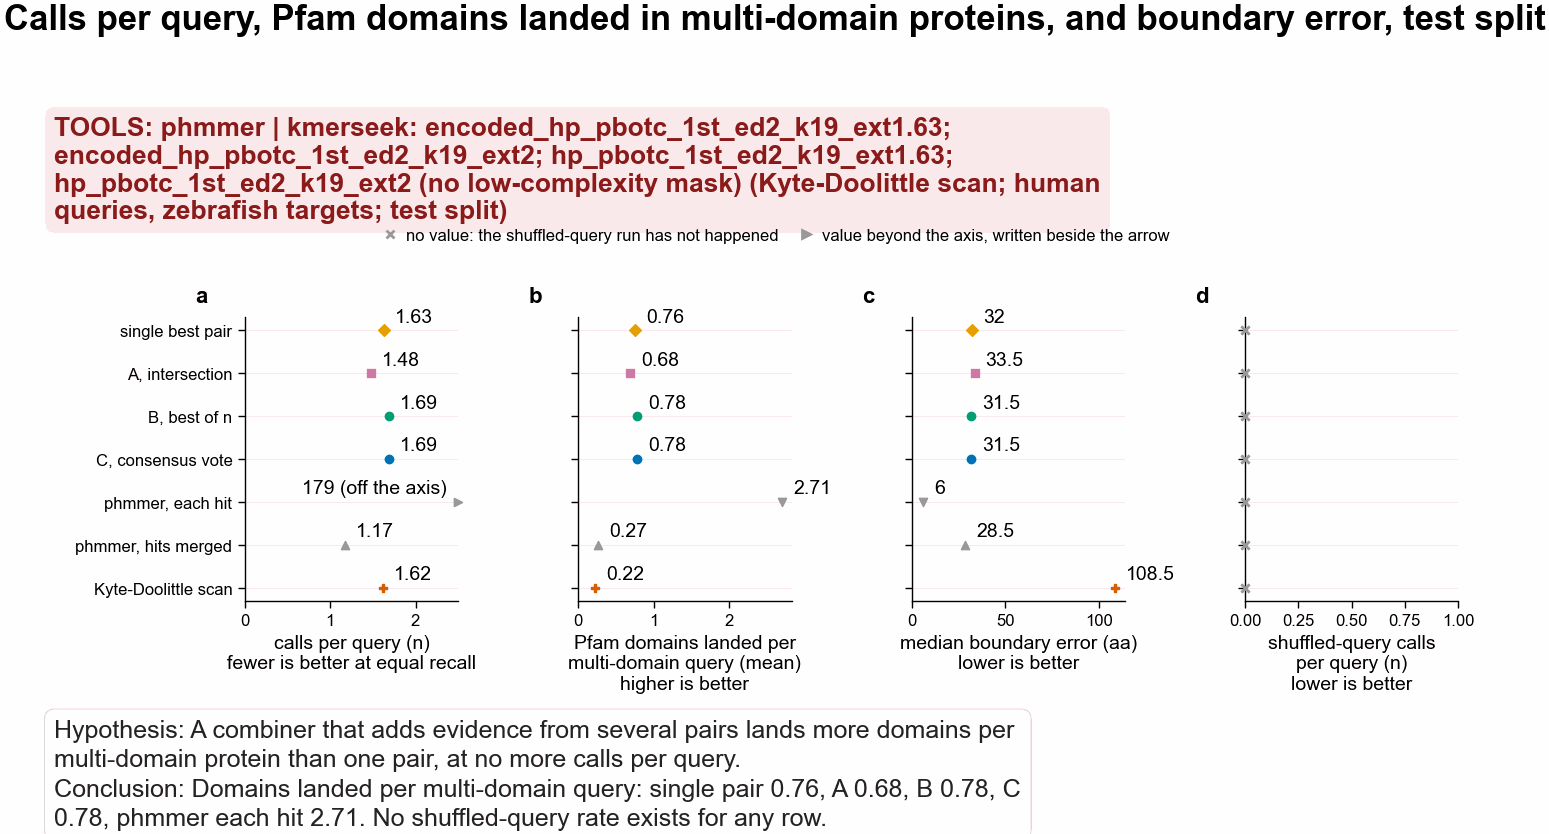

In [4]:
COLS = ["row", "calls_per_query", "precision_swissprot", "recall_swissprot", "precision_pfam",
        "recall_pfam", "shuffled_calls_per_query", "mean_pfam_domains_landed_multidomain",
        "median_boundary_error_pfam"]
COUNTS = ["row", "n_called", "n_called_on_swissprot_queries", "n_true_swissprot", "n_found_swissprot",
          "n_called_on_pfam_queries", "n_true_pfam", "n_found_pfam"]
print(tab.select(COLS).with_columns(pl.selectors.float().round(3)))
print("\ncounts behind the ratios (denominators: test queries x species =", N_QUERY_SPECIES,
      "; Swiss-Prot features =", nf_test["swissprot"], "; Pfam domains =", nf_test["pfam"], ")")
print(tab.select(COUNTS))

prov = []
for r in ROWS:
    for col in COLS[1:]:
        hit = check.filter((pl.col("row") == r) & (pl.col("column") == col))
        if col == "shuffled_calls_per_query":
            src = "not computed anywhere: no shuffled-query run (region_table_decoy.parquet absent)"
        elif hit.height:
            src = f"notebook {hit['notebook'][0]}, {hit['cell'][0]}; reproduced in 264"
        elif col == "calls_per_query":
            src = "264: n_called / test queries x species (n_called as in the counts table)"
        else:
            src = "first computed in 264 (score_spans)"
        prov.append(dict(row=r, column=col, source=src))
prov = pl.DataFrame(prov)
print(prov)
TABLE_OUT = FIG.parent / "notebooks" / "264_combiner_comparison_test_split.csv"
tab.select(COLS + COUNTS[1:]).write_csv(TABLE_OUT)
prov.write_csv(TABLE_OUT.with_name("264_combiner_comparison_provenance.csv"))
print(f"wrote {TABLE_OUT.name} and 264_combiner_comparison_provenance.csv")

# Figure: the columns that are not precision and recall, one panel each.
PANELS = [("calls_per_query", "calls per query (n)", "fewer is better at equal recall"),
          ("mean_pfam_domains_landed_multidomain", "Pfam domains landed per\nmulti-domain query (mean)", "higher is better"),
          ("median_boundary_error_pfam", "median boundary error (aa)", "lower is better"),
          ("shuffled_calls_per_query", "shuffled-query calls\nper query (n)", "lower is better")]
CALLS_XMAX = 2.5  # phmmer's per-hit count (about 179) is written at the edge instead
fig, axes = pf.figure(pf.TWO_COLUMN_MM, 62, ncols=4, sharey=True)
y = np.arange(len(ROWS))
for ax, (col, name, good) in zip(axes, PANELS):
    for yi, r in zip(y, ROWS):
        v = tab.filter(pl.col("row") == r)[col][0]
        if v is None:
            ax.scatter([0], [yi], marker="x", color=pf.GREY, clip_on=False, zorder=3)
        elif col == "calls_per_query" and v > CALLS_XMAX:
            ax.annotate(f"{v:.0f} (off the axis)", (CALLS_XMAX, yi), xytext=(-4, 3), textcoords="offset points", ha="right")
            ax.scatter([CALLS_XMAX], [yi], color=ROW_C[r], marker=">", clip_on=False, zorder=3)
        else:
            ax.scatter([v], [yi], color=ROW_C[r], marker=ROW_M[r], zorder=3)
            ax.annotate(f"{v:.0f}" if col == "median_boundary_error_pfam" and v == int(v) else f"{v:.1f}" if col == "median_boundary_error_pfam" else f"{v:.2f}", (v, yi), xytext=(4, 3), textcoords="offset points")
    for yi in y:
        ax.axhline(yi, color="#E2E8F0", lw=0.3, zorder=0)
    ax.set_xlabel(f"{name}\n{good}")
    ax.set_xlim(left=0)
axes[-1].set_xlim(0, 1)
axes[0].set_xlim(0, CALLS_XMAX)
axes[0].set_yticks(y, ROWS)
axes[0].invert_yaxis()
fig.legend([Line2D([], [], ls="none", marker="x", color=pf.GREY),
            Line2D([], [], ls="none", marker=">", color=pf.GREY)],
           ["no value: the shuffled-query run has not happened", "value beyond the axis, written beside the arrow"],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
for ax, letter in zip(axes, "abcd"):
    pf.panel_label(ax, letter)
fig.tight_layout(rect=(0, 0, 1, 0.92))
t = {r["row"]: r for r in tab.to_dicts()}
notebook_figure(
    fig, FIG / "264_calls_domains_boundary_per_method_midi_plus_zebrafish_test",
    tools=mu.tools_text(comparison=["hmmer3_phmmer"], kmerseek=ARMS, lc=False,
                        note="Kyte-Doolittle scan; human queries, zebrafish targets; test split"),
    title="Calls per query, Pfam domains landed in multi-domain proteins, and boundary error, test split",
    hypothesis="A combiner that adds evidence from several pairs lands more domains per multi-domain "
               "protein than one pair, at no more calls per query.",
    conclusion=(f"Domains landed per multi-domain query: single pair {t['single best pair']['mean_pfam_domains_landed_multidomain']:.2f}, "
                f"A {t['A, intersection']['mean_pfam_domains_landed_multidomain']:.2f}, B {t['B, best of n']['mean_pfam_domains_landed_multidomain']:.2f}, "
                f"C {t['C, consensus vote']['mean_pfam_domains_landed_multidomain']:.2f}, phmmer each hit "
                f"{t['phmmer, each hit']['mean_pfam_domains_landed_multidomain']:.2f}. No shuffled-query rate exists for any row."),
)

## Precision against recall

One point per row, in two panels: Swiss-Prot features and Pfam domains. Up and to the right
is better. Point size was meant to show the shuffled-query call rate; that run has not
happened, so every point has the same size. B and C call the same 822 regions, so their
points sit on top of each other: C is the large ring, B the filled point inside it.

shape: (7, 6)
┌─────────────────────┬─────────────────┬─────────────────────┬──────────────────┬────────────────┬─────────────┐
│ row                 ┆ calls_per_query ┆ precision_swissprot ┆ recall_swissprot ┆ precision_pfam ┆ recall_pfam │
│ ---                 ┆ ---             ┆ ---                 ┆ ---              ┆ ---            ┆ ---         │
│ str                 ┆ f64             ┆ f64                 ┆ f64              ┆ f64            ┆ f64         │
╞═════════════════════╪═════════════════╪═════════════════════╪══════════════════╪════════════════╪═════════════╡
│ single best pair    ┆ 1.632           ┆ 0.354               ┆ 0.073            ┆ 0.543          ┆ 0.312       │
│ A, intersection     ┆ 1.478           ┆ 0.341               ┆ 0.063            ┆ 0.547          ┆ 0.291       │
│ B, best of n        ┆ 1.688           ┆ 0.359               ┆ 0.076            ┆ 0.543          ┆ 0.32        │
│ C, consensus vote   ┆ 1.688           ┆ 0.359               ┆ 0.076     

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_74380/3980586726.py:43: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.9))


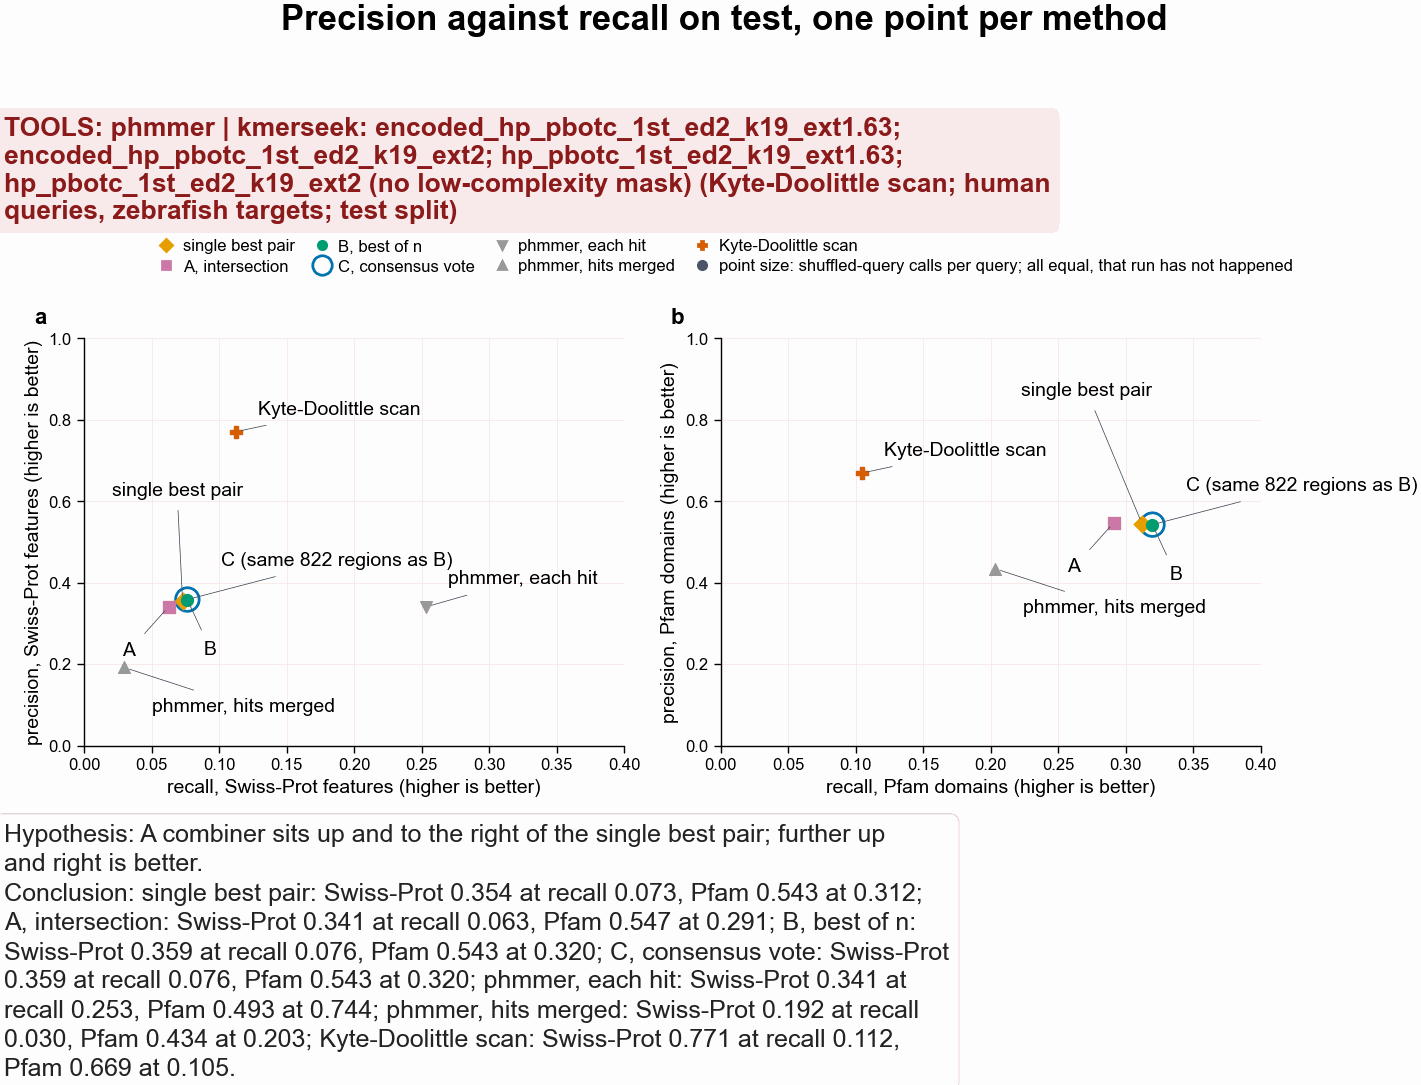

In [5]:
pr = tab.select("row", "calls_per_query", "precision_swissprot", "recall_swissprot", "precision_pfam", "recall_pfam")
print(pr.with_columns(pl.selectors.float().round(3)))
no_decoy = tab["shuffled_calls_per_query"].null_count() == tab.height
SIZE = 18  # the one size every point gets while no shuffled-query rate exists
LABEL = {"single best pair": "single best pair", "A, intersection": "A", "B, best of n": "B",
         "C, consensus vote": "C (same 822 regions as B)", "phmmer, each hit": "phmmer, each hit",
         "phmmer, hits merged": "phmmer, hits merged", "Kyte-Doolittle scan": "Kyte-Doolittle scan"}
# Label offsets in points (dx, dy, alignment), set by eye so labels clear the four kmerseek
# points that sit within 0.03 of each other.
LABEL_AT = {"single best pair": (-8, 22, "right"), "A, intersection": (-12, -16, "right"),
            "B, best of n": (6, -18, "left"), "C, consensus vote": (12, 14, "left"),
            "phmmer, each hit": (8, 10, "left"), "phmmer, hits merged": (10, -14, "left"),
            "Kyte-Doolittle scan": (8, 8, "left")}
LABEL_AT_PANEL = {("swissprot", "single best pair"): (-2, 40, "center"),
                  ("pfam", "single best pair"): (-20, 48, "center")}

fig, axes = pf.figure(pf.TWO_COLUMN_MM, 75, ncols=2)
for ax, ts, name in zip(axes, rb.TRUTH_SETS, ("Swiss-Prot features", "Pfam domains")):
    for r in ROWS:
        d = tab.filter(pl.col("row") == r).row(0, named=True)
        if r == "C, consensus vote":
            ax.scatter([d[f"recall_{ts}"]], [d[f"precision_{ts}"]], s=SIZE * 4, facecolors="none",
                       edgecolors=ROW_C[r], linewidths=1, zorder=2)
        else:
            ax.scatter([d[f"recall_{ts}"]], [d[f"precision_{ts}"]], s=SIZE, color=ROW_C[r], marker=ROW_M[r], zorder=3)
        dx, dy, ha = LABEL_AT_PANEL.get((ts, r), LABEL_AT[r])
        ax.annotate(LABEL[r], (d[f"recall_{ts}"], d[f"precision_{ts}"]), xytext=(dx, dy), textcoords="offset points",
                    ha=ha, va="center", arrowprops=dict(arrowstyle="-", lw=0.3, color="#4A5568"))
    ax.set_xlabel(f"recall, {name} (higher is better)")
    ax.set_ylabel(f"precision, {name} (higher is better)")
    ax.set_xlim(0, 0.4)
    ax.set_ylim(0, 1)
    ax.grid(color="#E2E8F0", lw=0.3)
handles = [Line2D([], [], ls="none", marker=ROW_M[r], color=ROW_C[r]) if r != "C, consensus vote"
           else Line2D([], [], ls="none", marker="o", mfc="none", mec=ROW_C[r], ms=7) for r in ROWS]
labels = ROWS[:]
handles.append(Line2D([], [], ls="none", marker="o", color="#4A5568", ms=3))
labels.append("point size: shuffled-query calls per query; all equal, that run has not happened" if no_decoy
              else "point size: shuffled-query calls per query")
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.0))
for ax, letter in zip(axes, "ab"):
    pf.panel_label(ax, letter)
fig.tight_layout(rect=(0, 0, 1, 0.9))
notebook_figure(
    fig, FIG / "264_precision_recall_per_method_swissprot_pfam_midi_plus_zebrafish_test",
    tools=mu.tools_text(comparison=["hmmer3_phmmer"], kmerseek=ARMS, lc=False,
                        note="Kyte-Doolittle scan; human queries, zebrafish targets; test split"),
    title="Precision against recall on test, one point per method",
    hypothesis="A combiner sits up and to the right of the single best pair; further up and right is better.",
    conclusion="; ".join(f"{r['row']}: Swiss-Prot {r['precision_swissprot']:.3f} at recall {r['recall_swissprot']:.3f}, "
                         f"Pfam {r['precision_pfam']:.3f} at {r['recall_pfam']:.3f}" for r in pr.to_dicts()) + ".",
)

## What an independent check found, computed here

A separate check recomputed every number of the table from the parquet with its own code;
all matched. It raised four points about what the rows mean. Each is computed below from
the same files, so the numbers come from this cell.

1. B and C keep every merged region in the table, and the single pair's threshold
   (9.97) is its loosest tune point, so none of the three applies a cut.
2. The merge rule joins overlapping calls into one stretch. A stretch that covers two
   domains lands in neither, so merging can only lower "domains landed" (a call can land
   in two domains only where the two domains overlap). The kmerseek rows are merged; the
   phmmer row they were compared with is not. Below, kmerseek's own calls left unmerged.
3. "phmmer, each hit" counts the same stretch of the query once per target protein that
   hit it; collapsing those repeats changes its precision.
4. The Kyte-Doolittle scan only reports segments above 1.6, so the frozen threshold keeps
   all of them.

merged regions on test: 822; kept by B: 822; kept by C: 822
Kyte-Doolittle test segments: 789; below the frozen threshold 1.6: 0


shape: (4, 8)
┌──────────────────────────────────────────────────┬──────────┬─────────────────────┬──────────────────┬────────────────┬─────────────┬──────────────────────────────────────┬────────────────────────────┐
│ row                                              ┆ n_called ┆ precision_swissprot ┆ recall_swissprot ┆ precision_pfam ┆ recall_pfam ┆ mean_pfam_domains_landed_multidomain ┆ median_boundary_error_pfam │
│ ---                                              ┆ ---      ┆ ---                 ┆ ---              ┆ ---            ┆ ---         ┆ ---                                  ┆ ---                        │
│ str                                              ┆ i64      ┆ f64                 ┆ f64              ┆ f64            ┆ f64         ┆ f64                                  ┆ f64                        │
╞══════════════════════════════════════════════════╪══════════╪═════════════════════╪══════════════════╪════════════════╪═════════════╪═══════════════════════════════════

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_74380/3355774494.py:57: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.86))


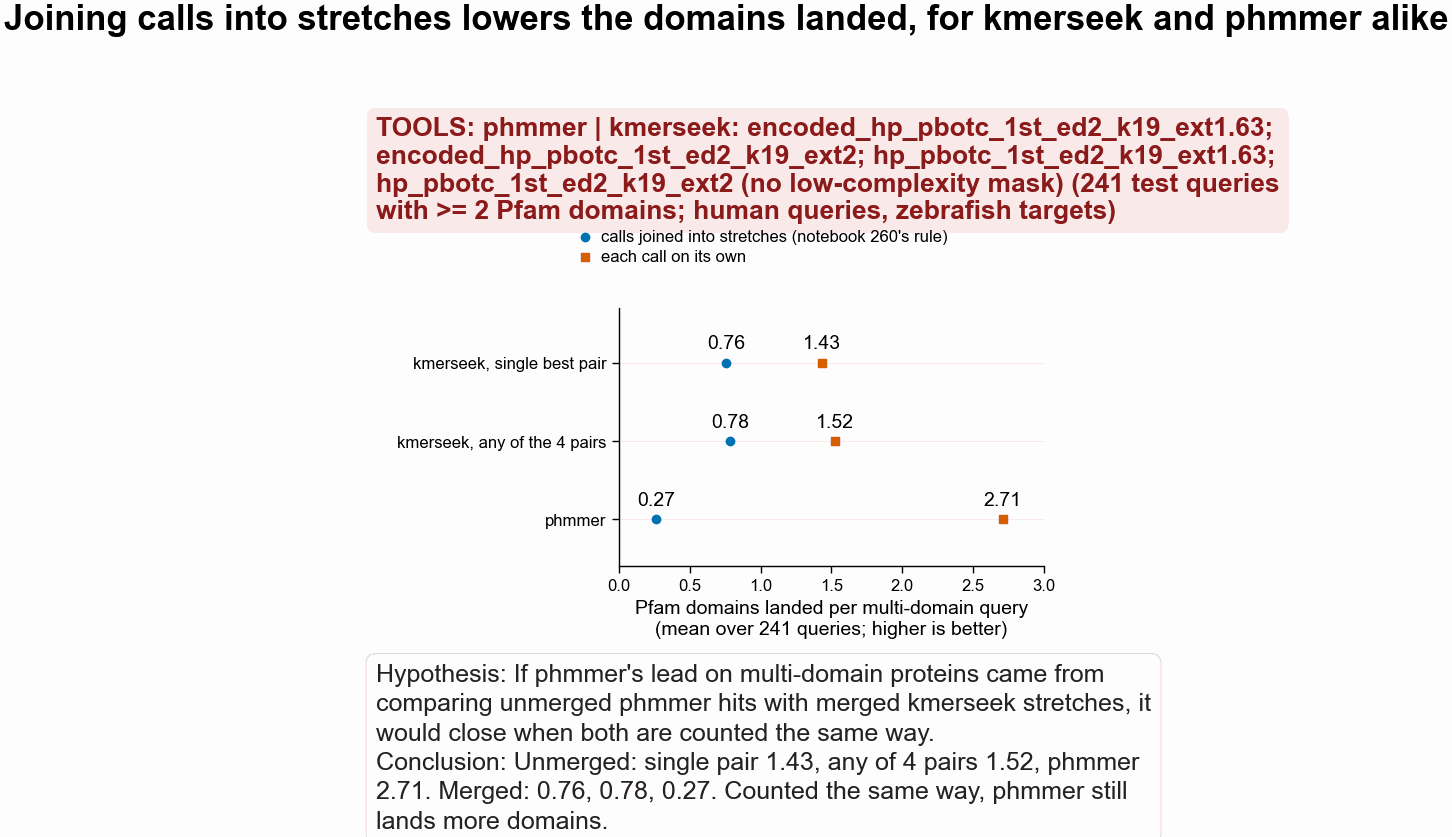

In [6]:
raw = (calls.with_columns(split=rt.query_split(pl.col("accession"))).filter(pl.col("split") == SPLIT)
       .select("accession", "species", "arm", "region_evalue", start="call_start", end="call_end"))
print(f"merged regions on test: {test_scores.height}; kept by B: {spans['B, best of n'].height}; "
      f"kept by C: {spans['C, consensus vote'].height}")
print(f"Kyte-Doolittle test segments: {kd.regions.height}; below the frozen threshold {THR_KD:.3g}: "
      f"{kd.regions.filter(pl.col('kd_score') < THR_KD).height}")
UNMERGED = {
    "single best pair, its own calls unmerged": raw.filter((pl.col("arm") == SINGLE) & (pl.col("region_evalue") <= THR_SINGLE)),
    "any of the 4 pairs (B, C), calls unmerged": raw,
    "phmmer, each hit": spans["phmmer, each hit"],
    "phmmer, each hit, repeated query spans collapsed": spans["phmmer, each hit"].unique(subset=["accession", "species", "start", "end"]),
}
un = pl.DataFrame([dict(row=r, **score_spans(s.select("accession", "species", "start", "end"))[0])
                   for r, s in UNMERGED.items()], infer_schema_length=None)
print(un.select("row", "n_called", "precision_swissprot", "recall_swissprot", "precision_pfam", "recall_pfam",
                "mean_pfam_domains_landed_multidomain", "median_boundary_error_pfam")
      .with_columns(pl.selectors.float().round(3)))
calls_per_q = raw.group_by("accession", "species").len().sort("len", descending=True)
print("test queries with the most unmerged kmerseek calls:")
print(calls_per_q.head(5).join(queries.select("accession", "hgnc_symbol"), on="accession", how="left"))

def glued(s: pl.DataFrame) -> dict:
    # Called regions that overlap two or more Pfam domains of their query, and how many of
    # those land (half or more of the region) in none.
    s = s.with_row_index("rid")
    pf_pairs = rt.region_truth_pairs(s.select("rid", "accession", "species", "start", "end"),
                                     pf_dom.select("accession", "feature", "feature_start", "feature_end"), "start", "end")
    g = pf_pairs.group_by("rid").agg(n_dom=pl.len(), landed_any=(pl.col("landed") >= rt.LANDED_MIN).any())
    multi_ = g.filter(pl.col("n_dom") >= 2)
    return dict(n_called=s.height, n_over_two_or_more_domains=multi_.height,
                of_those_landed_in_none=multi_.filter(~pl.col("landed_any")).height)
glue = pl.DataFrame([dict(row=r, **glued(spans[r])) for r in ["single best pair", "A, intersection", "B, best of n", "phmmer, hits merged"]])
print(glue)

lab = {"merged (the table)": [t["single best pair"]["mean_pfam_domains_landed_multidomain"],
                              t["B, best of n"]["mean_pfam_domains_landed_multidomain"],
                              t["phmmer, hits merged"]["mean_pfam_domains_landed_multidomain"]],
       "unmerged": [un["mean_pfam_domains_landed_multidomain"][0], un["mean_pfam_domains_landed_multidomain"][1],
                    un["mean_pfam_domains_landed_multidomain"][2]]}
names = ["kmerseek, single best pair", "kmerseek, any of the 4 pairs", "phmmer"]
fig, ax = pf.figure(pf.ONE_COLUMN_MM, 55)
yy = np.arange(len(names))
MERGE_C = {"merged (the table)": pf.OKABE_ITO["blue"], "unmerged": pf.OKABE_ITO["vermillion"]}
for k, mk in (("merged (the table)", "o"), ("unmerged", "s")):
    ax.scatter(lab[k], yy, color=MERGE_C[k], marker=mk, label=k, zorder=3)
    for xv, yv in zip(lab[k], yy):
        ax.annotate(f"{xv:.2f}", (xv, yv), xytext=(0, 5), textcoords="offset points", ha="center")
for yv in yy:
    ax.axhline(yv, color="#E2E8F0", lw=0.3, zorder=0)
ax.set_yticks(yy, names)
ax.invert_yaxis()
ax.set_xlim(0, 3)
ax.set_ylim(len(names) - 0.4, -0.7)
ax.set_xlabel("Pfam domains landed per multi-domain query\n(mean over 241 queries; higher is better)")
h, l = ax.get_legend_handles_labels()
fig.legend(h, ["calls joined into stretches (notebook 260's rule)", "each call on its own"], loc="upper center", ncol=1, bbox_to_anchor=(0.55, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.86))
notebook_figure(
    fig, FIG / "264_domains_landed_merged_vs_unmerged_kmerseek_phmmer_midi_plus_zebrafish_test",
    tools=mu.tools_text(comparison=["hmmer3_phmmer"], kmerseek=ARMS, lc=False,
                        note="241 test queries with >= 2 Pfam domains; human queries, zebrafish targets"),
    title="Joining calls into stretches lowers the domains landed, for kmerseek and phmmer alike",
    hypothesis="If phmmer's lead on multi-domain proteins came from comparing unmerged phmmer hits with merged "
               "kmerseek stretches, it would close when both are counted the same way.",
    conclusion=(f"Unmerged: single pair {lab['unmerged'][0]:.2f}, any of 4 pairs {lab['unmerged'][1]:.2f}, phmmer "
                f"{lab['unmerged'][2]:.2f}. Merged: {lab['merged (the table)'][0]:.2f}, {lab['merged (the table)'][1]:.2f}, "
                f"{lab['merged (the table)'][2]:.2f}. Counted the same way, phmmer still lands more domains."),
)

## The decision rule

For each combiner, against the single best pair on test: Pfam recall and calls per query,
and whether it beats the pair by the rule at the top (at least as good on both, strictly
better on one).

single best pair: 795 calls, 1.632 per query, Pfam recall 0.3122 (370 domains), 2.149 calls per domain found
shape: (3, 9)
┌───────────────────┬──────────┬─────────────────┬─────────────┬──────────────┬──────────────────────────┬──────────────────────────────┬─────────────────────────────┬──────────────┐
│ row               ┆ n_called ┆ calls_per_query ┆ recall_pfam ┆ n_found_pfam ┆ recall_pfam_minus_single ┆ calls_per_query_minus_single ┆ calls_per_pfam_domain_found ┆ beats_single │
│ ---               ┆ ---      ┆ ---             ┆ ---         ┆ ---          ┆ ---                      ┆ ---                          ┆ ---                         ┆ ---          │
│ str               ┆ i64      ┆ f64             ┆ f64         ┆ i64          ┆ f64                      ┆ f64                          ┆ f64                         ┆ bool         │
╞═══════════════════╪══════════╪═════════════════╪═════════════╪══════════════╪══════════════════════════╪══════════════════════════════╪════════

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_74380/1669186198.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.86))


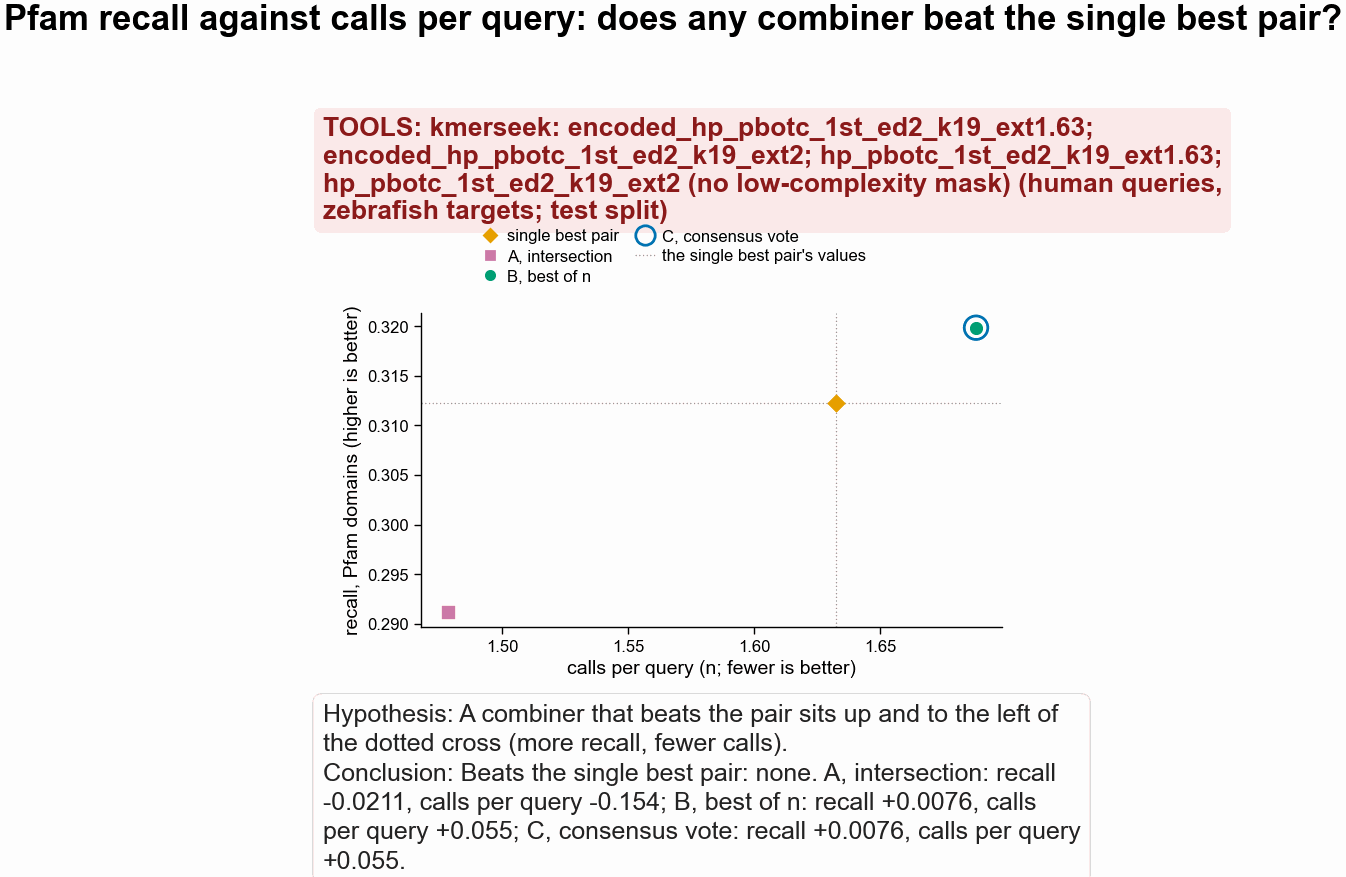

In [7]:
s0 = tab.filter(pl.col("row") == "single best pair").row(0, named=True)
dec = (tab.filter(pl.col("row").is_in(["A, intersection", "B, best of n", "C, consensus vote"]))
       .select("row", "n_called", "calls_per_query", "recall_pfam", "n_found_pfam")
       .with_columns(recall_pfam_minus_single=pl.col("recall_pfam") - s0["recall_pfam"],
                     calls_per_query_minus_single=pl.col("calls_per_query") - s0["calls_per_query"],
                     calls_per_pfam_domain_found=pl.col("n_called") / pl.col("n_found_pfam"))
       .with_columns(beats_single=((pl.col("recall_pfam_minus_single") >= 0) & (pl.col("calls_per_query_minus_single") <= 0)
                                   & ((pl.col("recall_pfam_minus_single") > 0) | (pl.col("calls_per_query_minus_single") < 0)))))
print(f"single best pair: {s0['n_called']} calls, {s0['calls_per_query']:.3f} per query, Pfam recall "
      f"{s0['recall_pfam']:.4f} ({s0['n_found_pfam']} domains), {s0['n_called'] / s0['n_found_pfam']:.3f} calls per domain found")
print(dec.with_columns(pl.selectors.float().round(4)))
print("combiners that beat the single best pair:", dec.filter(pl.col("beats_single"))["row"].to_list() or "none")

fig, ax = pf.figure(pf.ONE_COLUMN_MM, 60)
for r in ["single best pair", "A, intersection", "B, best of n", "C, consensus vote"]:
    d = tab.filter(pl.col("row") == r).row(0, named=True)
    if r == "C, consensus vote":
        ax.scatter([d["calls_per_query"]], [d["recall_pfam"]], s=SIZE * 4, facecolors="none", edgecolors=ROW_C[r], linewidths=1)
    else:
        ax.scatter([d["calls_per_query"]], [d["recall_pfam"]], s=SIZE, color=ROW_C[r], marker=ROW_M[r], zorder=3)
ax.axvline(s0["calls_per_query"], color=pf.GREY, lw=0.5, ls=":")
ax.axhline(s0["recall_pfam"], color=pf.GREY, lw=0.5, ls=":")
ax.set_xlabel("calls per query (n; fewer is better)")
ax.set_ylabel("recall, Pfam domains (higher is better)")
rows4 = ["single best pair", "A, intersection", "B, best of n", "C, consensus vote"]
h = [Line2D([], [], ls="none", marker=ROW_M[r], color=ROW_C[r]) if r != "C, consensus vote"
     else Line2D([], [], ls="none", marker="o", mfc="none", mec=ROW_C[r], ms=7) for r in rows4]
h.append(Line2D([], [], color=pf.GREY, lw=0.5, ls=":"))
fig.legend(h, rows4 + ["the single best pair's values"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.86))
notebook_figure(
    fig, FIG / "264_recall_vs_calls_per_query_combiners_vs_single_pair_midi_plus_zebrafish_test",
    tools=mu.tools_text(kmerseek=ARMS, lc=False, note="human queries, zebrafish targets; test split"),
    title="Pfam recall against calls per query: does any combiner beat the single best pair?",
    hypothesis="A combiner that beats the pair sits up and to the left of the dotted cross (more recall, fewer calls).",
    conclusion=("Beats the single best pair: " + (", ".join(dec.filter(pl.col("beats_single"))["row"].to_list()) or "none") +
                ". " + "; ".join(f"{r['row']}: recall {r['recall_pfam_minus_single']:+.4f}, calls per query "
                                  f"{r['calls_per_query_minus_single']:+.3f}" for r in dec.to_dicts()) + "."),
)

# Summary and Conclusions

## Background

Notebooks 261, 262 and 263 each froze one way of combining kmerseek's alphabet-ksize pairs
on the tune half of the queries. This notebook scores all three, the single best pair,
phmmer and a Kyte-Doolittle scan on the test half, from one scoring function, and fits
nothing. The region table has 4 pairs, all hp_pbotc_1st_ed2 at k=19 (two extension
penalties, encoded and built-in), human queries against zebrafish only, and no
shuffled-query run. The numbers change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* No combiner beats the single best pair by the rule set at the top. The pair calls 795
  test regions (1.63 per query) and finds 370 of 1_185 Pfam domains (recall 0.312).
* Combiner A (intersection of two pairs) calls 720 regions (1.48 per query) and finds 345
  domains (recall 0.291): 75 fewer calls, 25 fewer domains.
* Combiners B (best of n) and C (consensus vote) call the same 822 regions (1.69 per
  query) and find 379 domains (recall 0.320): 27 more calls, 9 more domains. Both keep
  every merged region in notebook 260's table, so neither applies a cut here.
* Precision barely moves across the kmerseek rows: Pfam 0.543 to 0.547, Swiss-Prot 0.341
  to 0.359.
* On 241 test queries with at least two Pfam domains, phmmer lands in a mean of 2.71
  domains per query; the kmerseek rows land in 0.68 (A) to 0.78 (B and C).
* Part of that gap is the merge rule. A merged region that covers two domains lands in
  neither: 220 of B's 822 regions overlap two or more Pfam domains, and 141 of those land
  in none. Counted call by call, kmerseek lands 1.43 (single pair) and 1.52 (any of the 4
  pairs) domains per query, still about half of phmmer's 2.71.
* Merging phmmer's hits by the same rule drops it to 0.27 domains per query and Pfam
  recall from 0.744 to 0.203.
* kmerseek's region ends are a median 31.5 to 33.5 residues from the Pfam domain ends
  (21.5 to 22 unmerged); phmmer's are 6 residues off.
* The Kyte-Doolittle scan has the highest Swiss-Prot precision (0.771) and lands 0.22
  domains per multi-domain query.
* No shuffled-query run exists, so no row has a false-call rate.

## Analysis Details

The four pairs are one search at two extension penalties, run two ways. They agree on 85%
to 97% of their calls (notebook 263), so B and C add the few regions where they differ
and A removes them. The comparison these combiners were built for, pairs from different
alphabets, needs the full run.

B's frozen threshold (corrected E-value 39.9) and C's frozen vote (one vote at E < 10) both
keep all 822 test merged regions. The single pair's threshold (E <= 9.97) is the loosest
point on its tune curve. Notebook 260 kept only calls with E < 10, so the table itself is
the only cut every row shares.

The "single best pair" row follows notebooks 262 and 263: it scores the merged regions,
built from all four pairs' calls, in which that pair has a call. Its own 47_349 unmerged
test calls have Pfam recall 0.466 but Pfam precision 0.075, because a few zinc-finger
proteins carry thousands of calls each (ZNF184 has 24_272).

phmmer's "each hit" row counts one stretch of the query once per target protein it hit.
Counting each stretch once lowers the calls from 87_244 to 53_222 and raises Pfam
precision from 0.493 to 0.578; recall, domains landed and boundary error do not change.

A merged region can land in two domains only where the two domains overlap. So joining
calls lowers "domains landed" and cannot raise it, for kmerseek and phmmer alike.

An independent check, run with its own code and without this notebook, recomputed every
number in the table from the parquet and found them all. It confirmed that no test
accession is in the tune half and that every frozen setting was chosen on tune. It could
not compare the pairs of the real and shuffled-query tables, because the shuffled-query
table does not exist.

## Supplementary Information

- Input: `~/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet`
  (6_140 rows, sha256 c936f3884dbbb25f..., the same in `261_intersection_panel.yaml`,
  `262_best_of_n_threshold.yaml` and `263_consensus_vote.yaml`), `region_table_truth_pairs.parquet`
  and the `reduced/` call files, from notebook 260 on PR #88.
- Truth: `human_domain_truth.parquet` (Pfam) and `human_swissprot_truth.parquet`
  (Swiss-Prot) under the midi-plus run directory.
- phmmer: `regions/hmmer3_phmmer/human_vs_zebrafish.hmmer3_phmmer.tsv.gz`, midi-plus region
  benchmark (1-2 Sept 2026), per-domain i-Evalue < 10.
- Query sequences: QfO 2020_04 human proteome, `UP000005640_9606.fasta`.
- Outputs: `264_combiner_comparison_test_split.csv` (the table with its counts) and
  `264_combiner_comparison_provenance.csv` (the notebook and cell behind every number).
- Code: `notebooks/264_build_notebook.py`, reusing `region_table_260.py` and
  `region_combiner_261/262/263.py`; figures use `pubfig.py` and `nature.mplstyle`.
- To rebuild on the full run: rebuild notebook 260's table with the shuffled-query twin,
  re-execute 261, 262 and 263, then this notebook.

## References

- [Notebook 260](260_kmerseek_region_table.ipynb): the region table and the merge rule.
- [Notebook 261](261_combiner_a_intersection_panel.ipynb): combiner A.
- [Notebook 262](262_combiner_b_best_of_n.ipynb): combiner B, the single best pair and the
  Kyte-Doolittle scan.
- [Notebook 263](263_combiner_c_consensus_vote.ipynb): combiner C.

In [8]:
summary_md = r"""
# Summary and Conclusions

## Background

Notebooks 261, 262 and 263 each froze one way of combining kmerseek's alphabet-ksize pairs
on the tune half of the queries. This notebook scores all three, the single best pair,
phmmer and a Kyte-Doolittle scan on the test half, from one scoring function, and fits
nothing. The region table has 4 pairs, all hp_pbotc_1st_ed2 at k=19 (two extension
penalties, encoded and built-in), human queries against zebrafish only, and no
shuffled-query run. The numbers change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* No combiner beats the single best pair by the rule set at the top. The pair calls 795
  test regions (1.63 per query) and finds 370 of 1_185 Pfam domains (recall 0.312).
* Combiner A (intersection of two pairs) calls 720 regions (1.48 per query) and finds 345
  domains (recall 0.291): 75 fewer calls, 25 fewer domains.
* Combiners B (best of n) and C (consensus vote) call the same 822 regions (1.69 per
  query) and find 379 domains (recall 0.320): 27 more calls, 9 more domains. Both keep
  every merged region in notebook 260's table, so neither applies a cut here.
* Precision barely moves across the kmerseek rows: Pfam 0.543 to 0.547, Swiss-Prot 0.341
  to 0.359.
* On 241 test queries with at least two Pfam domains, phmmer lands in a mean of 2.71
  domains per query; the kmerseek rows land in 0.68 (A) to 0.78 (B and C).
* Part of that gap is the merge rule. A merged region that covers two domains lands in
  neither: 220 of B's 822 regions overlap two or more Pfam domains, and 141 of those land
  in none. Counted call by call, kmerseek lands 1.43 (single pair) and 1.52 (any of the 4
  pairs) domains per query, still about half of phmmer's 2.71.
* Merging phmmer's hits by the same rule drops it to 0.27 domains per query and Pfam
  recall from 0.744 to 0.203.
* kmerseek's region ends are a median 31.5 to 33.5 residues from the Pfam domain ends
  (21.5 to 22 unmerged); phmmer's are 6 residues off.
* The Kyte-Doolittle scan has the highest Swiss-Prot precision (0.771) and lands 0.22
  domains per multi-domain query.
* No shuffled-query run exists, so no row has a false-call rate.

## Analysis Details

The four pairs are one search at two extension penalties, run two ways. They agree on 85%
to 97% of their calls (notebook 263), so B and C add the few regions where they differ
and A removes them. The comparison these combiners were built for, pairs from different
alphabets, needs the full run.

B's frozen threshold (corrected E-value 39.9) and C's frozen vote (one vote at E < 10) both
keep all 822 test merged regions. The single pair's threshold (E <= 9.97) is the loosest
point on its tune curve. Notebook 260 kept only calls with E < 10, so the table itself is
the only cut every row shares.

The "single best pair" row follows notebooks 262 and 263: it scores the merged regions,
built from all four pairs' calls, in which that pair has a call. Its own 47_349 unmerged
test calls have Pfam recall 0.466 but Pfam precision 0.075, because a few zinc-finger
proteins carry thousands of calls each (ZNF184 has 24_272).

phmmer's "each hit" row counts one stretch of the query once per target protein it hit.
Counting each stretch once lowers the calls from 87_244 to 53_222 and raises Pfam
precision from 0.493 to 0.578; recall, domains landed and boundary error do not change.

A merged region can land in two domains only where the two domains overlap. So joining
calls lowers "domains landed" and cannot raise it, for kmerseek and phmmer alike.

An independent check, run with its own code and without this notebook, recomputed every
number in the table from the parquet and found them all. It confirmed that no test
accession is in the tune half and that every frozen setting was chosen on tune. It could
not compare the pairs of the real and shuffled-query tables, because the shuffled-query
table does not exist.

## Supplementary Information

- Input: `~/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet`
  (6_140 rows, sha256 c936f3884dbbb25f..., the same in `261_intersection_panel.yaml`,
  `262_best_of_n_threshold.yaml` and `263_consensus_vote.yaml`), `region_table_truth_pairs.parquet`
  and the `reduced/` call files, from notebook 260 on PR #88.
- Truth: `human_domain_truth.parquet` (Pfam) and `human_swissprot_truth.parquet`
  (Swiss-Prot) under the midi-plus run directory.
- phmmer: `regions/hmmer3_phmmer/human_vs_zebrafish.hmmer3_phmmer.tsv.gz`, midi-plus region
  benchmark (1-2 Sept 2026), per-domain i-Evalue < 10.
- Query sequences: QfO 2020_04 human proteome, `UP000005640_9606.fasta`.
- Outputs: `264_combiner_comparison_test_split.csv` (the table with its counts) and
  `264_combiner_comparison_provenance.csv` (the notebook and cell behind every number).
- Code: `notebooks/264_build_notebook.py`, reusing `region_table_260.py` and
  `region_combiner_261/262/263.py`; figures use `pubfig.py` and `nature.mplstyle`.
- To rebuild on the full run: rebuild notebook 260's table with the shuffled-query twin,
  re-execute 261, 262 and 263, then this notebook.

## References

- [Notebook 260](260_kmerseek_region_table.ipynb): the region table and the merge rule.
- [Notebook 261](261_combiner_a_intersection_panel.ipynb): combiner A.
- [Notebook 262](262_combiner_b_best_of_n.ipynb): combiner B, the single best pair and the
  Kyte-Doolittle scan.
- [Notebook 263](263_combiner_c_consensus_vote.ipynb): combiner C.
"""
print(summary_md)


# Summary and Conclusions

## Background

Notebooks 261, 262 and 263 each froze one way of combining kmerseek's alphabet-ksize pairs
on the tune half of the queries. This notebook scores all three, the single best pair,
phmmer and a Kyte-Doolittle scan on the test half, from one scoring function, and fits
nothing. The region table has 4 pairs, all hp_pbotc_1st_ed2 at k=19 (two extension
penalties, encoded and built-in), human queries against zebrafish only, and no
shuffled-query run. The numbers change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* No combiner beats the single best pair by the rule set at the top. The pair calls 795
  test regions (1.63 per query) and finds 370 of 1_185 Pfam domains (recall 0.312).
* Combiner A (intersection of two pairs) calls 720 regions (1.48 per query) and finds 345
  domains (recall 0.291): 75 fewer calls, 25 fewer domains.
* Combiners B (best of n) and C (consensus vote) call the same 822 regions (1.69 per
  query) 